<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Manuel Helas

### Ejercicio 1:

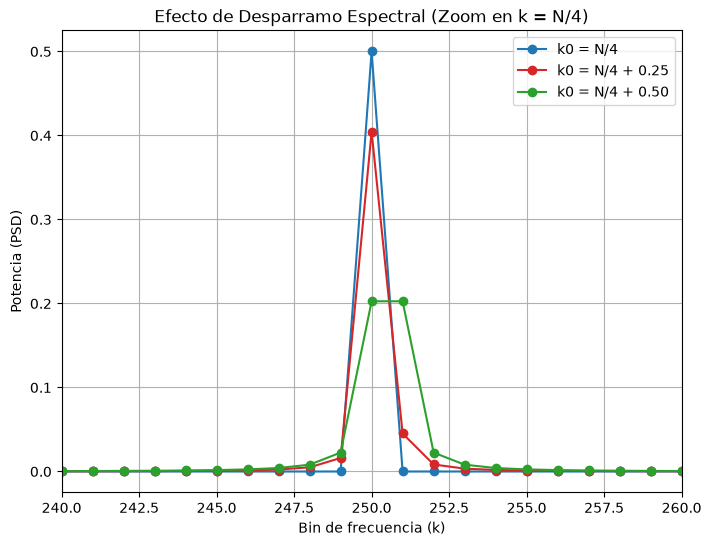

Potencia total de las PSD (Parseval):
Caso k0 = N/4:      1.0000
Caso k0 = N/4+0.25: 0.9990
Caso k0 = N/4+0.50: 1.0000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.close('all')
# Parámetros del sistema
N = 1000          # Número de muestras
fs = 1000         # Frecuencia de muestreo en Hz (arbitraria)
ff = fs / N       # Resolución espectral
n = np.arange(N)  # Vector de muestras
k0 = 1
A = np.sqrt(2)
f0 = k0 * ff
dc = 0
ph = 0



def mi_funcion_sen(A=1, dc=0, f0=1, ph=0, nn=N, fs=fs):
  tt = np.arange(start=0, stop=nn / fs, step=1 / fs)
  xx = (A * np.sin(2 * np.pi * f0 * tt + ph)) + dc
  return (tt, xx)

k0 = N/4
f0 = k0 * ff
tt, xx1 = mi_funcion_sen(A=A, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)
k0 = N/4 + 0.25
f0 = k0 * ff
tt, xx2 = mi_funcion_sen(A=A, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)
k0 = N/4 + 0.50
f0 = k0 * ff
tt, xx3 = mi_funcion_sen(A=A, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)

#%% calculo fft y grafico espectro de potencia 



PSDx1 = (np.abs(np.fft.fft(xx1))**2) / (N**2)
PSDx2 = (np.abs(np.fft.fft(xx2))**2) / (N**2)
PSDx3 = (np.abs(np.fft.fft(xx3))**2) / (N**2)


k = np.arange(N)
plt.figure(figsize=(8, 6))
plt.plot(k, PSDx1, 'o-', label="k0 = N/4", color="tab:blue")
plt.plot(k, PSDx2, 'o-', label="k0 = N/4 + 0.25", color="tab:red")
plt.plot(k, PSDx3, 'o-', label="k0 = N/4 + 0.50", color="tab:green")


centro = int(N/4)
margen = 10 
plt.xlim(centro - margen, centro + margen)

plt.title("Efecto de Desparramo Espectral (Zoom en k = N/4)")
plt.xlabel("Bin de frecuencia (k)")
plt.ylabel("Potencia (PSD)")
plt.legend()
plt.grid(True)
plt.show()

# Verificación de potencia unitaria usando Parseval
pot_psd_1 = np.sum(PSDx1)
pot_psd_2 = np.sum(PSDx2)
pot_psd_3 = np.sum(PSDx3)

print("Potencia total de las PSD (Parseval):")
print(f"Caso k0 = N/4:      {pot_psd_1:.4f}")
print(f"Caso k0 = N/4+0.25: {pot_psd_2:.4f}")
print(f"Caso k0 = N/4+0.50: {pot_psd_3:.4f}")

Viendo el grafico se puede apreciar como afecta la pequeña diferencia de k0 en los 3 espectros, en el caso cuando k0 = N/4 toda la energia esra concentrada en el bin 250 (la energia total es 0,5 y no 1 debido a que la transformada devide la potencia por igual a ambos lados de la frecuencia de nyquist), en el caso de k0 = N/4 + 0,25, se ve que gran parte de la potencia cae en el bin 250 debido a que este es el mas cercano pero otra parte se desparrama y cae en el bin 251 mientras que cuando k0 = N/4 + 0,50 al  estar justo entreo los 2 bins, la potencia se devidide en partes iguales en los 2 bins por lo que la fuga es mas grande que en +0,25.

### Ejercicio 2
Se puede ver que por mas que el haya una fuga, la potencia de la señal sigue siendo la misma que en un comienzo solo que desparramada en otros bins, no se pierde potencia (la potencia de k0 = N/4 + 0,25 no da 1 debido a que cuando se calcula la potencia se eleva al cuadrado todo y sigue dando distinto a un numero entero de ciclos a diferencia de k0 = N/4 + 0,50) 

### Ejercicio 3

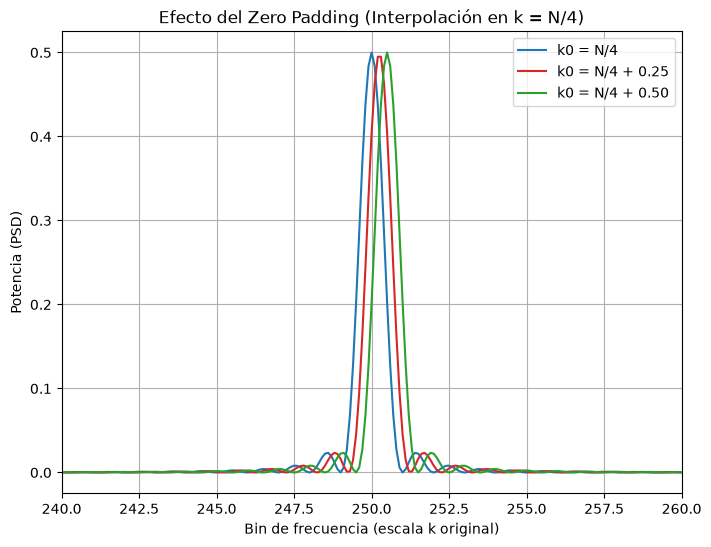

Potencia total de las PSD (Parseval):
Caso k0 = N/4:      10.0000
Caso k0 = N/4+0.25: 9.9900
Caso k0 = N/4+0.50: 10.0000


In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.close('all')
# Parámetros del sistema
N = 1000          # Número de muestras
fs = 1000         # Frecuencia de muestreo en Hz (arbitraria)
ff = fs / N       # Resolución espectral
n = np.arange(N)  # Vector de muestras
k0 = 1
A = np.sqrt(2)
f0 = k0 * ff
dc = 0
ph = 0



def mi_funcion_sen(A=1, dc=0, f0=1, ph=0, nn=N, fs=fs):
  tt = np.arange(start=0, stop=nn / fs, step=1 / fs)
  xx = (A * np.sin(2 * np.pi * f0 * tt + ph)) + dc
  return (tt, xx)

k0 = N/4
f0 = k0 * ff
tt, xx1 = mi_funcion_sen(A=A, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)
k0 = N/4 + 0.25
f0 = k0 * ff
tt, xx2 = mi_funcion_sen(A=A, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)
k0 = N/4 + 0.50
f0 = k0 * ff
tt, xx3 = mi_funcion_sen(A=A, dc=dc, f0=f0, ph=ph, nn=N, fs=fs)

#%% Grafico espectro con padding

PSDx1 = (np.abs(np.fft.fft(xx1))**2) / (N**2)
PSDx2 = (np.abs(np.fft.fft(xx2))**2) / (N**2)
PSDx3 = (np.abs(np.fft.fft(xx3))**2) / (N**2)


ceros = np.zeros(9 * N)


xx1_pad = np.concatenate((xx1, ceros))
xx2_pad = np.concatenate((xx2, ceros))
xx3_pad = np.concatenate((xx3, ceros))


X1_pad = np.fft.fft(xx1_pad)
X2_pad = np.fft.fft(xx2_pad)
X3_pad = np.fft.fft(xx3_pad)

# PSD: Se sigue dividiendo por N**2 (el N original) porque 
# los ceros no aportan energía. La amplitud sigue dependiendo del N original.
PSD1_pad = (np.abs(X1_pad)**2) / (N**2)
PSD2_pad = (np.abs(X2_pad)**2) / (N**2)
PSD3_pad = (np.abs(X3_pad)**2) / (N**2)


N_pad = len(xx1_pad)
k_pad = np.arange(N_pad) / (N_pad / N) 


plt.figure(figsize=(8, 6))


plt.plot(k_pad, PSD1_pad,  label="k0 = N/4", color="tab:blue")
plt.plot(k_pad, PSD2_pad, label="k0 = N/4 + 0.25", color="tab:red")
plt.plot(k_pad, PSD3_pad, label="k0 = N/4 + 0.50", color="tab:green")

centro = int(N/4)
margen = 10 
plt.xlim(centro - margen, centro + margen)

plt.title("Efecto del Zero Padding (Interpolación en k = N/4)")
plt.xlabel("Bin de frecuencia (escala k original)")
plt.ylabel("Potencia (PSD)")
plt.legend()
plt.grid(True)
plt.show()

# Verificación de potencia unitaria usando Parseval
pot_psdpad_1 = np.sum(PSD1_pad)
pot_psdpad_2 = np.sum(PSD2_pad)
pot_psdpad_3 = np.sum(PSD3_pad)

print("Potencia total de las PSD (Parseval):")
print(f"Caso k0 = N/4:      {pot_psdpad_1:.4f}")
print(f"Caso k0 = N/4+0.25: {pot_psdpad_2:.4f}")
print(f"Caso k0 = N/4+0.50: {pot_psdpad_3:.4f}")

Viendo el gráfico se puede apreciar cómo, luego de aplicar el padding (agregar ceros al final de la señal), las curvas quedan mucho más suaves debido a que los valores ya no saltan de 1 en uno, sino de 0,1 en 0,1. Con esto no estamos aumentando la resolución espectral real de la señal (porque no agregamos más datos originales o más tiempo de grabación), sino que estamos haciendo una interpolación. Es decir, agregamos más puntos de cálculo para ver el espectro con más detalle.

También se hace evidente que, al ver la curva completa, ninguna de las señales tiene su energía concentrada en un solo bin, sino que siempre existió esa forma de campana con desparramo (fuga). La diferencia clave es que, al avanzar de 0,1 en 0,1, el caso de k0 = N/4 + 0,50 ahora tiene un bin que cae exactamente en la punta de la campana (en 250,5), por lo que podemos capturar ese pico máximo de energía. En cambio, en k0 = N/4 + 0,25 el pico máximo de la señal sigue cayendo a medio camino entre dos bines (250,2 y 250,3). Básicamente, el padding nos sirve para ver la forma real de la fuga, revelando dónde estaba el verdadero pico que antes nos perdíamos.

Ahora porque la campana llega hasta 0,5 pero tiene mas valores distintos de 0. Esta es una de las propiedades del 0 padding, al final estamos agregando 9000 muestras mas para poder ver con mas detalle el espectro pero esto genera que calculando la potencia como se puede ver esta nos da 10 veces mayor debido a que tenemos 10 veces mas muestras.